# Test rozwiniętej autorskiej architektury CNN

Celem eksperymentu jest ocena drugiej wersji autorskiej architektury konwolucyjnej CNN.

Opracowano rozwiniętą wersję architektury, w której po części konwolucyjnej zastosowano dodatkową warstwę w pełni połączoną.

Nowa architektura zachowuje część konwolucyjną poprzedniego modelu, natomiast głowica klasyfikacyjna została rozszerzona do postaci:

256 → 128 → 92.

In [ ]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.preprocessing import (
    gamma_correction,
    build_preprocessing_train_transform,
    build_preprocessing_eval_transform,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.custom_cnn_v2 import (
    create_custom_cnn_v2,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(
    42
)


print(
    "PROJECT_ROOT:",
    PROJECT_ROOT,
)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)


HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "custom_cnn_v2_screening"
)


FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)


VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)


TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "DEVICE:",
    DEVICE,
)

PROJECT_ROOT: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska
DEVICE: cpu


## 1. Konfiguracja eksperymentu

In [2]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-3
RANDOM_SEED = 42
PREPROCESSING_METHOD = "gamma"
GAMMA_VALUE = 1.5

LIGHTING_BRIGHTNESS_RANGE = (
    0.3,
    1.3,
)


LIGHTING_CONTRAST_RANGE = (
    0.8,
    1.2,
)


LIGHTING_PROBABILITY = 0.8


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "Rozdzielczość:",
    IMAGE_SIZE,
)

print(
    "Batch size:",
    BATCH_SIZE,
)

print(
    "Liczba epok:",
    EPOCHS,
)

print(
    "Learning rate:",
    LEARNING_RATE,
)

print(
    "Preprocessing:",
    PREPROCESSING_METHOD,
)

print(
    "Gamma:",
    GAMMA_VALUE,
)

print(
    "Zakres jasności:",
    LIGHTING_BRIGHTNESS_RANGE,
)

print(
    "Zakres kontrastu:",
    LIGHTING_CONTRAST_RANGE,
)

print(
    "Prawdopodobieństwo augmentacji:",
    LIGHTING_PROBABILITY,
)

Rozdzielczość: 224
Batch size: 32
Liczba epok: 20
Learning rate: 0.001
Preprocessing: gamma
Gamma: 1.5
Zakres jasności: (0.3, 1.3)
Zakres kontrastu: (0.8, 1.2)
Prawdopodobieństwo augmentacji: 0.8


## 2. Wczytanie manifestów i mapowanie klas

In [3]:
train_df = pd.read_csv(
    TRAIN_PATH
)


validation_df = pd.read_csv(
    VALIDATION_PATH
)


test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes),
)

print(
    "TRAIN:",
    len(train_df),
)

print(
    "VALIDATION:",
    len(validation_df),
)

print(
    "TEST_FINAL:",
    len(test_df),
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacje treningowe

W celu zapewnienia porównywalności z wcześniejszymi eksperymentami wykorzystano wybraną konfigurację preprocessingu i augmentacji.

Zastosowano:

- korekcję gamma γ = 1.5,
- augmentację oświetleniową,
- zmianę jasności w zakresie 0.3–1.3,
- zmianę kontrastu w zakresie 0.8–1.2,
- prawdopodobieństwo augmentacji równe 0.8,
- zmianę rozdzielczości do 224 × 224 pikseli,
- losową rotację do ±10°,
- normalizację zgodną ze standardem wykorzystanym wcześniej w projekcie.

In [4]:
base_train_transform = (
    build_preprocessing_train_transform(
        method=PREPROCESSING_METHOD,
        image_size=IMAGE_SIZE,
        gamma=GAMMA_VALUE,
    )
)


eval_transform = (
    build_preprocessing_eval_transform(
        method=PREPROCESSING_METHOD,
        image_size=IMAGE_SIZE,
        gamma=GAMMA_VALUE,
    )
)


lighting_augmentation = (
    RandomLightingAugmentation(
        brightness_range=
            LIGHTING_BRIGHTNESS_RANGE,

        contrast_range=
            LIGHTING_CONTRAST_RANGE,

        probability=
            LIGHTING_PROBABILITY,
    )
)


train_transform = transforms.Compose([
    lighting_augmentation,
    base_train_transform,
])

## 4. Kontrola wizualna transformacji

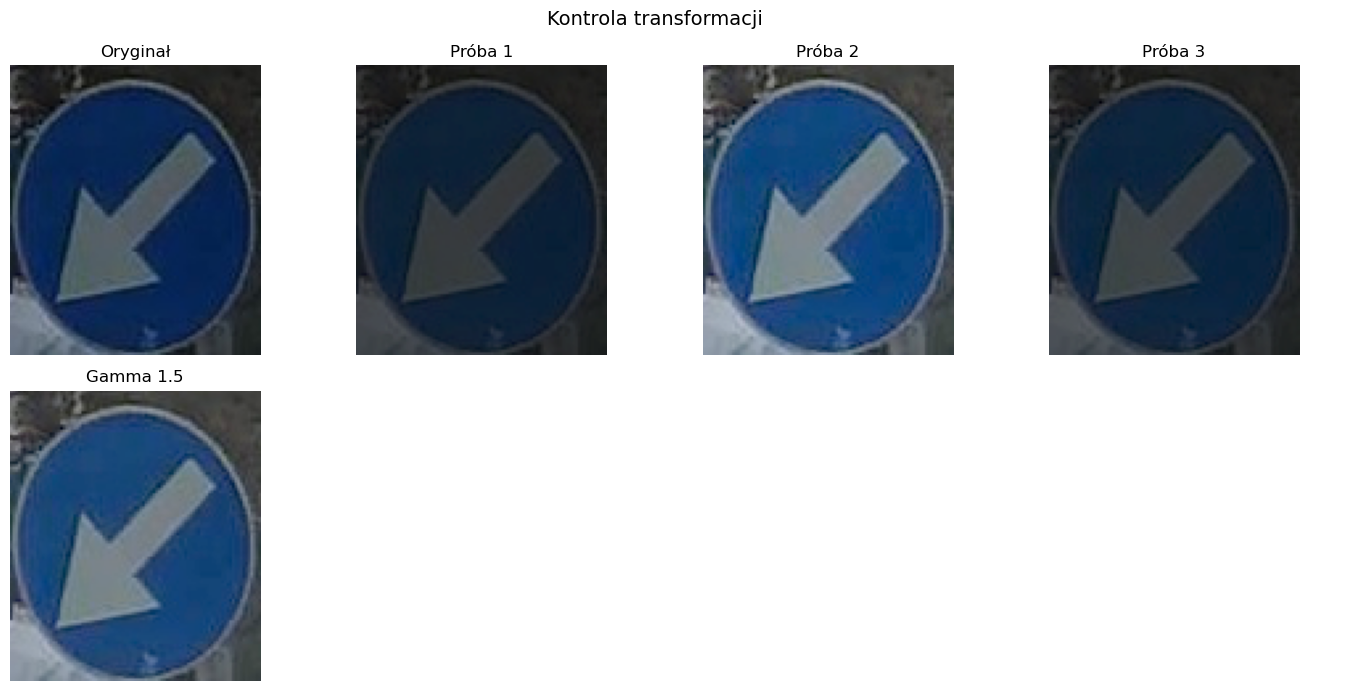

In [5]:
sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = (
    Image.open(
        sample_path
    )
    .convert("RGB")
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)


axes[0, 0].imshow(
    sample_image
)

axes[0, 0].set_title(
    "Oryginał"
)

axes[0, 0].axis(
    "off"
)


for index in range(
    1,
    4,
):

    augmentation = (
        RandomLightingAugmentation(
            brightness_range=
                LIGHTING_BRIGHTNESS_RANGE,

            contrast_range=
                LIGHTING_CONTRAST_RANGE,

            probability=1.0,
        )
    )


    transformed = (
        augmentation(
            sample_image
        )
    )


    if (
        PREPROCESSING_METHOD
        == "gamma"
    ):

        transformed = (
            gamma_correction(
                transformed,
                gamma=GAMMA_VALUE,
            )
        )


    axes[
        0,
        index
    ].imshow(
        transformed
    )


    axes[
        0,
        index
    ].set_title(
        f"Próba {index}"
    )


    axes[
        0,
        index
    ].axis(
        "off"
    )


gamma_image = (
    gamma_correction(
        sample_image,
        gamma=GAMMA_VALUE,
    )
)


axes[
    1,
    0
].imshow(
    gamma_image
)


axes[
    1,
    0
].set_title(
    "Gamma 1.5"
)


axes[
    1,
    0
].axis(
    "off"
)


for index in range(
    1,
    4,
):

    axes[
        1,
        index
    ].axis(
        "off"
    )


fig.suptitle(
    "Kontrola transformacji",
    fontsize=14,
)


plt.tight_layout()
plt.show()

## 5. Przygotowanie DataLoaderów

In [6]:
train_dataset = TrafficSignDataset(
    TRAIN_PATH,
    class_to_idx,
    transform=train_transform,
)


validation_dataset = TrafficSignDataset(
    VALIDATION_PATH,
    class_to_idx,
    transform=eval_transform,
)


weighted_sampler = (
    build_weighted_sampler(
        TRAIN_PATH
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


print(
    "Liczba próbek treningowych:",
    len(train_dataset),
)

print(
    "Liczba próbek walidacyjnych:",
    len(validation_dataset),
)

Liczba próbek treningowych: 14232
Liczba próbek walidacyjnych: 2512


## 6. Rozwinięta autorska architektura CNN

Druga wersja autorskiej sieci zachowuje wcześniejszą część konwolucyjną, ale rozszerza głowicę klasyfikacyjną.

Po ekstrakcji cech za pomocą Adaptive Average Pooling zastosowano warstwę liniową 256 → 128 z funkcją ReLU i Dropout, a następnie warstwę klasyfikacyjną 128 → 92.

Rozwiązanie ma zwiększyć zdolność modelu do przekształcania cech konwolucyjnych w reprezentację właściwą dla 92 klas znaków drogowych.

In [7]:
model = create_custom_cnn_v2(
    num_classes=len(
        class_codes
    )
)


model = model.to(
    DEVICE
)


total_params = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


trainable_params = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


print(
    model
)


print(
    "\nLiczba wszystkich parametrów:",
    f"{total_params:,}",
)


print(
    "Liczba trenowalnych parametrów:",
    f"{trainable_params:,}",
)

CustomCNNV2(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

## 7. Trening

Model jest trenowany od początku z wykorzystaniem funkcji straty Cross Entropy i optymalizatora Adam.

In [8]:
set_seed(
    RANDOM_SEED
)


model = create_custom_cnn_v2(
    num_classes=len(
        class_codes
    )
).to(
    DEVICE
)


criterion = (
    nn.CrossEntropyLoss()
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


checkpoint_path = (
    CHECKPOINT_DIR
    / "custom_cnn_v2_screening.pt"
)


history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    checkpoint_path=checkpoint_path,
)


print(
    "\nTrening zakończony."
)


print(
    "Najlepszy Validation Macro F1:",
    f"{history['best_val_macro_f1']:.6f}",
)


print(
    "Czas treningu [s]:",
    f"{history['training_time_seconds']:.2f}",
)

Postęp treningu:   0%|          | 0/20 [00:00<?, ?it/s]

Epoka 1/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/20:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 17/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 18/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 19/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 20/20:   0%|          | 0/445 [00:00<?, ?it/s]


Trening zakończony.
Najlepszy Validation Macro F1: 0.756483
Czas treningu [s]: 16758.52


## 8. Historia treningu

In [9]:
history_df = pd.DataFrame({
    "train_loss":
        history[
            "train_loss"
        ],

    "train_accuracy":
        history[
            "train_accuracy"
        ],

    "val_loss":
        history[
            "val_loss"
        ],

    "val_accuracy":
        history[
            "val_accuracy"
        ],

    "val_macro_f1":
        history[
            "val_macro_f1"
        ],
})


history_path = (
    HISTORIES_DIR
    / "custom_cnn_v2_screening_history.csv"
)


history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig",
)


display(
    history_df
)

,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1
0,3.437995,0.087198,3.097642,0.130175,0.070232
1,2.972334,0.149944,2.759896,0.203424,0.125537
2,2.737693,0.196599,2.722419,0.208997,0.148259
3,2.525766,0.248735,2.406228,0.247213,0.209095
4,2.284466,0.309865,2.230683,0.283041,0.238709
5,2.082882,0.364320,2.039782,0.335589,0.294597
6,1.880895,0.421796,1.769827,0.450637,0.398406
7,1.677051,0.477656,1.716719,0.439490,0.396338
8,1.539861,0.519744,1.516080,0.549363,0.465809
9,1.382053,0.566681,1.441702,0.522293,0.503458


## 9. Wizualizacja procesu uczenia

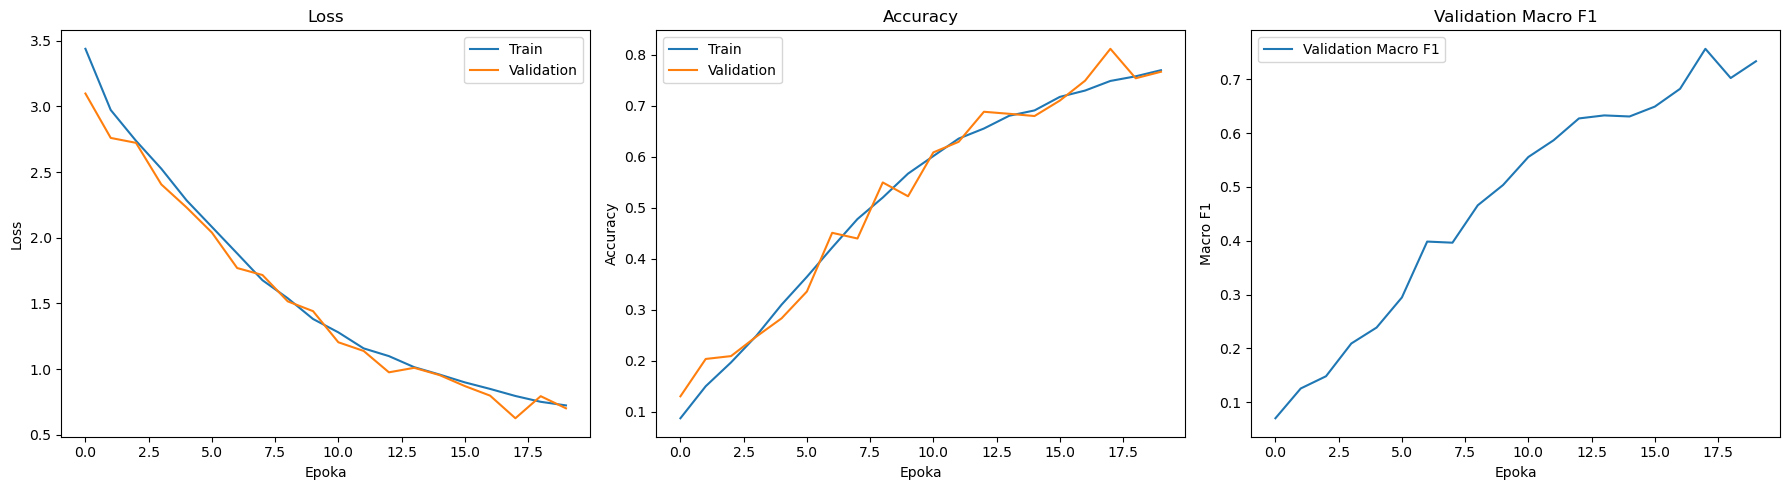

In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


axes[0].plot(
    history_df[
        "train_loss"
    ],
    label="Train",
)


axes[0].plot(
    history_df[
        "val_loss"
    ],
    label="Validation",
)


axes[0].set_title(
    "Loss"
)


axes[0].set_xlabel(
    "Epoka"
)


axes[0].set_ylabel(
    "Loss"
)


axes[0].legend()


axes[1].plot(
    history_df[
        "train_accuracy"
    ],
    label="Train",
)


axes[1].plot(
    history_df[
        "val_accuracy"
    ],
    label="Validation",
)


axes[1].set_title(
    "Accuracy"
)


axes[1].set_xlabel(
    "Epoka"
)


axes[1].set_ylabel(
    "Accuracy"
)


axes[1].legend()


axes[2].plot(
    history_df[
        "val_macro_f1"
    ],
    label="Validation Macro F1",
)


axes[2].set_title(
    "Validation Macro F1"
)


axes[2].set_xlabel(
    "Epoka"
)


axes[2].set_ylabel(
    "Macro F1"
)


axes[2].legend()


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_custom_cnn_v2_training_history.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 10. Standardowa skuteczność na zbiorze walidacyjnym

Po zakończeniu treningu model oceniono na zbiorze walidacyjnym.

Jako podstawowe metryki wykorzystano Accuracy, Macro Precision, Macro Recall oraz Macro F1.

In [11]:
y_val_true, y_val_pred, validation_inference_time = (
    predict(
        model,
        validation_loader,
        DEVICE,
    )
)


validation_metrics = (
    evaluate_predictions(
        y_val_true,
        y_val_pred,
    )
)


standard_validation = {

    "model":
        "CustomCNNV2",

    "accuracy":
        validation_metrics[
            "accuracy"
        ],

    "macro_precision":
        validation_metrics[
            "macro_precision"
        ],

    "macro_recall":
        validation_metrics[
            "macro_recall"
        ],

    "macro_f1":
        validation_metrics[
            "macro_f1"
        ],

    "training_time_seconds":
        history[
            "training_time_seconds"
        ],

    "inference_time_seconds":
        validation_inference_time,

    "parameters":
        total_params,
}


standard_validation_df = pd.DataFrame(
    [standard_validation]
)


display(
    standard_validation_df
)


standard_validation_df.to_csv(
    METRICS_DIR
    / "custom_cnn_v2_screening_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,inference_time_seconds,parameters
0,CustomCNNV2,0.811306,0.752427,0.825562,0.756483,16758.518278,53.799091,434140


## 11. Raport klasyfikacji

In [12]:
classification_report_df = (
    pd.DataFrame(
        validation_metrics[
            "classification_report"
        ]
    ).T
)


classification_report_df.to_csv(
    METRICS_DIR
    / "custom_cnn_v2_screening_classification_report.csv",
    encoding="utf-8-sig",
)


display(
    classification_report_df
)

,precision,recall,f1-score,support
0,0.827586,0.827586,0.827586,29.000000
1,0.400000,0.666667,0.500000,6.000000
2,0.714286,1.000000,0.833333,5.000000
3,0.714286,0.416667,0.526316,12.000000
4,1.000000,0.166667,0.285714,6.000000
...,...,...,...,...
90,0.714286,0.833333,0.769231,6.000000
91,0.200000,0.666667,0.307692,3.000000
accuracy,0.811306,0.811306,0.811306,0.811306
macro avg,0.752427,0.825562,0.756483,2512.000000


## 12. Macierz pomyłek

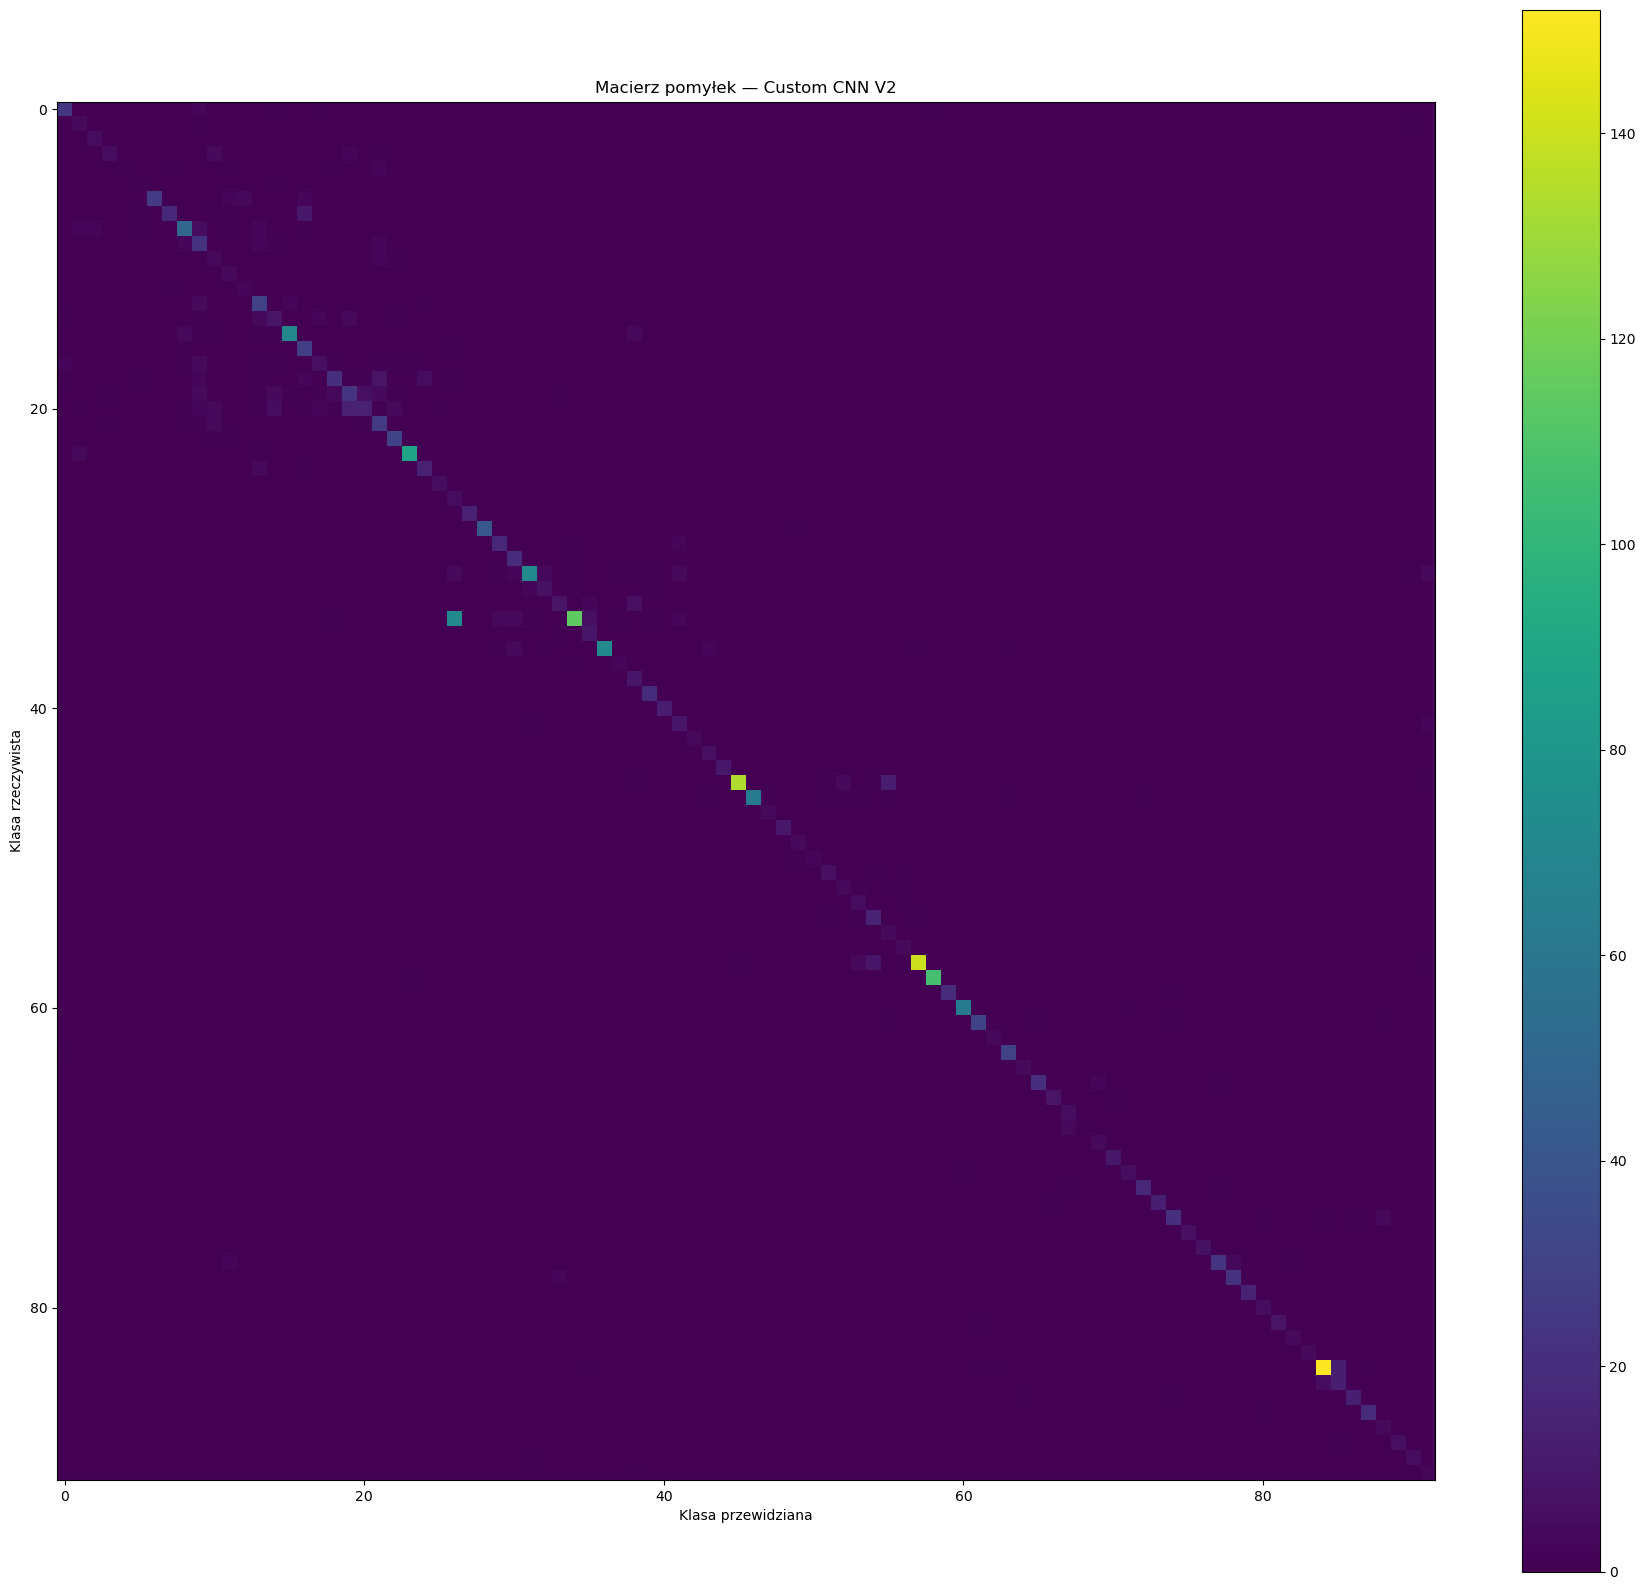

In [13]:
cm = (
    validation_metrics[
        "confusion_matrix"
    ]
)


fig, ax = plt.subplots(
    figsize=(18, 16)
)


im = ax.imshow(
    cm
)


ax.set_title(
    "Macierz pomyłek — Custom CNN V2"
)


ax.set_xlabel(
    "Klasa przewidziana"
)


ax.set_ylabel(
    "Klasa rzeczywista"
)


fig.colorbar(
    im,
    ax=ax,
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_custom_cnn_v2_confusion_matrix.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 13. Ocena odporności na kontrolowane zaciemnienie

W celu zachowania zgodności z wcześniejszymi eksperymentami model oceniono również na trzech wariantach kontrolowanego zaciemnienia:

- `dark_1`,
- `dark_2`,
- `dark_3`.

Do oceny odporności wykorzystywany jest zbiór walidacyjny.

In [14]:
def evaluate_lighting_variant(
    model,
    variant,
):

    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=eval_transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = (
        evaluate_predictions(
            y_true,
            y_pred,
        )
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 14. Ocena odporności na zaciemnienie

In [15]:
dark_results = []


for variant in DARK_VARIANTS:

    print(
        f"CustomCNNV2 | {variant}"
    )


    metrics = (
        evaluate_lighting_variant(
            model=model,
            variant=variant,
        )
    )


    dark_results.append(
        {
            "variant":
                variant,

            "factor":
                LIGHTING_FACTORS[
                    variant
                ],

            **metrics,
        }
    )


dark_results_df = pd.DataFrame(
    dark_results
)


display(
    dark_results_df
)


dark_results_df.to_csv(
    METRICS_DIR
    / "custom_cnn_v2_screening_dark_results.csv",
    index=False,
    encoding="utf-8-sig",
)

CustomCNNV2 | dark_1
CustomCNNV2 | dark_2
CustomCNNV2 | dark_3


,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,dark_1,0.7,2512,0.803742,0.751893,0.821836,0.753994,51.217989
1,dark_2,0.5,2512,0.788217,0.747484,0.813844,0.744804,51.751715
2,dark_3,0.3,2512,0.743631,0.719067,0.767410,0.698459,57.158786


## 15. Podsumowanie odporności

In [16]:
mean_dark_macro_f1 = (
    dark_results_df[
        "macro_f1"
    ].mean()
)


mean_dark_accuracy = (
    dark_results_df[
        "accuracy"
    ].mean()
)


dark3_macro_f1 = (
    dark_results_df.loc[
        dark_results_df[
            "variant"
        ] == "dark_3",
        "macro_f1",
    ].iloc[0]
)


standard_macro_f1 = (
    standard_validation[
        "macro_f1"
    ]
)


f1_drop_to_dark3 = (
    standard_macro_f1
    -
    dark3_macro_f1
)


robustness_summary = pd.DataFrame([
    {

        "model":
            "CustomCNNV2",

        "standard_macro_f1":
            standard_macro_f1,

        "mean_dark_macro_f1":
            mean_dark_macro_f1,

        "mean_dark_accuracy":
            mean_dark_accuracy,

        "dark3_macro_f1":
            dark3_macro_f1,

        "f1_drop_to_dark3":
            f1_drop_to_dark3,
    }
])


display(
    robustness_summary
)


robustness_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_v2_screening_robustness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,standard_macro_f1,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,f1_drop_to_dark3
0,CustomCNNV2,0.756483,0.732419,0.77853,0.698459,0.058024


## 16. Porównanie poziomów zaciemnienia

variant
dark_1    0.753994
dark_2    0.744804
dark_3    0.698459
Name: macro_f1, dtype: float64

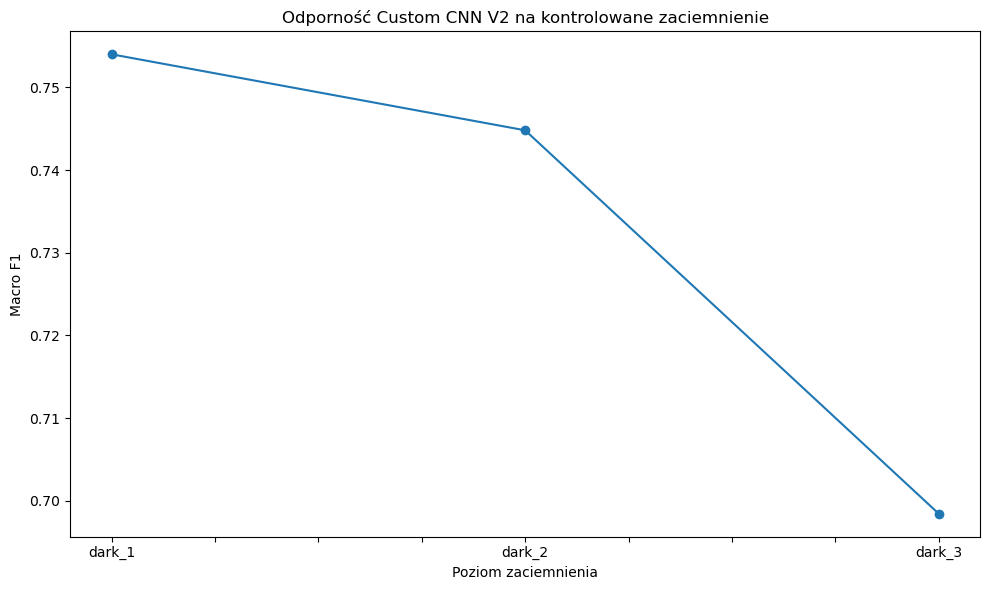

In [17]:
dark_plot = (
    dark_results_df
    .set_index(
        "variant"
    )[
        "macro_f1"
    ]
    .reindex(
        DARK_VARIANTS
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Odporność Custom CNN V2 "
    "na kontrolowane zaciemnienie"
)


ax.set_xlabel(
    "Poziom zaciemnienia"
)


ax.set_ylabel(
    "Macro F1"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "03_custom_cnn_v2_dark_robustness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

In [18]:
screening_summary = pd.DataFrame([
    {

        "model":
            "CustomCNNV2",

        "parameters":
            total_params,

        "training_time_seconds":
            history[
                "training_time_seconds"
            ],

        "standard_accuracy":
            standard_validation[
                "accuracy"
            ],

        "standard_macro_precision":
            standard_validation[
                "macro_precision"
            ],

        "standard_macro_recall":
            standard_validation[
                "macro_recall"
            ],

        "standard_macro_f1":
            standard_validation[
                "macro_f1"
            ],

        "mean_dark_macro_f1":
            mean_dark_macro_f1,

        "mean_dark_accuracy":
            mean_dark_accuracy,

        "dark3_macro_f1":
            dark3_macro_f1,

        "f1_drop_to_dark3":
            f1_drop_to_dark3,
    }
])


display(
    screening_summary
)


screening_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_v2_screening_final_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,parameters,training_time_seconds,standard_accuracy,standard_macro_precision,standard_macro_recall,standard_macro_f1,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,f1_drop_to_dark3
0,CustomCNNV2,434140,16758.518278,0.811306,0.752427,0.825562,0.756483,0.732419,0.77853,0.698459,0.058024
